In [1]:
#r "nuget:ScottPlot, 5.0.*"
#r "D:\projects\Practical\First-year-practical\task14\bin\Debug\net9.0\task14.dll"

Installed Packages ScottPlot, 5.0.55

Loading extensions from `C:\Users\user\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`

In [2]:
using System;
using System.Diagnostics;
using task14;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) => 
    w.Write(((ScottPlot.Plot)p).GetPngHtml(400, 300)), HtmlFormatter.MimeType);
Stopwatch stopwatch = new Stopwatch();

In [22]:
// Однопоточная реализация решения интеграла методом трапеций
double SolveIntegral(double a, double b, Func<Double, Double> function, double step) 
{
    double area = 0;
    for (double i = a; i < b; i += step)
    {
        area += (function(i) + function(i+step)) * step / 2;
    }
    return area;
}

Func <double, double> SIN = (double x) => Math.Sin(x);

In [ ]:
// Нахождение оптимального шага

double[] steps = { 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6 };
double[] results = new double[6];
double[] singleThreadTime = new double[6];

for(int i = 5; i >= 0; i--) {
    double[] curResults = new double[10];
    double curTime = 0;
    for (int j = 0; j < 10; j++) {
        stopwatch.Start();
        double result = SolveIntegral(-100, 100, SIN, steps[i]);
        stopwatch.Stop();
        curResults[j] = result;
        curTime += stopwatch.Elapsed.TotalMilliseconds;
        stopwatch.Reset();
    }
    results[i] = curResults.Average();
    singleThreadTime[i] = curTime / 10;
}

for (int i = 0; i < 6; i++) 
{
    Console.WriteLine($"Шаг {steps[i]:E0}: {results[i]:G4} {singleThreadTime[i]:G4} миллисекунд");
}

Шаг 1E-001: -0.05064 0.3553 миллисекунд
Шаг 1E-002: -1.456E-11 2.745 миллисекунд
Шаг 1E-003: -1.15E-10 28.38 миллисекунд
Шаг 1E-004: -2.224E-09 285.6 миллисекунд
Шаг 1E-005: -2.08E-08 2817 миллисекунд
Шаг 1E-006: -3.439E-07 2.758E+04 миллисекунд


Для определения наилучшего шага использована однопоточная реализация. По полученным данным можно увидеть, что любой шаг, кроме первого, вычисляет результат с погрешностью, меньшей 1e-4. Для наглядности в работе использован шаг 1e-3.


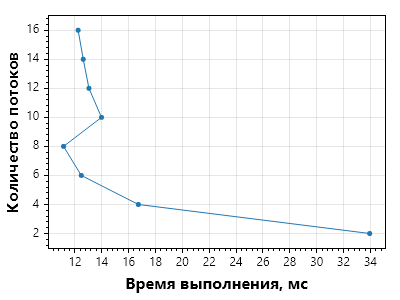

In [27]:
// Сравнение времени выполнения при разном количестве потоков
double[] multiThreadTime = new double[8];
int[] numOfThreads = new int[8];

for (int i = 1; i < 9; i++) 
{
    numOfThreads[i-1] = i*2;
    double curTime = 0;
    for (int j = 0; j < 100; j++) 
    {
        stopwatch.Start();
        DefiniteIntegral.Solve(-100, 100, SIN, 1e-3, i);
        stopwatch.Stop();
        curTime += stopwatch.Elapsed.TotalMilliseconds;
        stopwatch.Reset();
    }
    multiThreadTime[i-1] = curTime / 100;
}

ScottPlot.Plot plt = new ScottPlot.Plot();
plt.Add.Scatter(multiThreadTime, numOfThreads);
plt.XLabel("Время выполнения, мс");
plt.YLabel("Количество потоков");

plt

Из графика можно увидеть, что наилучшую производительность обеспечивает 8 потоков.

In [30]:
double singleThreadPerformance = singleThreadTime[2];
double multiThreadPerformance = multiThreadTime[3];

Console.WriteLine("Производительность при вычислении интгерала синуса от -100 до 100 с шагом 1e-3:");
Console.WriteLine($"Однопоточная реализация: {singleThreadPerformance:F3} мс");
Console.WriteLine($"Многопоточная реалзация (8 потоков): {multiThreadPerformance:F3} мс");
Console.WriteLine($"Разница производительности: {(singleThreadPerformance - multiThreadPerformance) / multiThreadPerformance:P2}");

Производительность при вычислении интгерала синуса от -100 до 100 с шагом 1e-3:
Однопоточная реализация: 28.381 мс
Многопоточная реалзация (8 потоков): 11.155 мс
Разница производительности: 154.43%
